# Vežbe 7: Early stopping i uvod u konvolucione neuronske mreže

U ovom notebook-u nastavljamo rad sa **feedforward neuronskim mrežama** nad skupom slika **Fashion-MNIST** i uvodimo osnovne koncepte **konvolucionih neuronskih mreža**.

Prvi deo notebook-a predstavlja proširenje prethodnih vežbi, kroz uvođenje tehnike **early stopping** za kontrolu procesa treniranja modela.

Drugi deo notebook-a uvodi osnovne gradivne elemente konvolucionih neuronskih mreža, sa posebnim fokusom na:

- konvolucione slojeve,
- pooling slojeve,
- način na koji se kod slika čuva prostorna struktura podataka,
- razliku između feedforward i konvolucionih neuronskih mreža.


## 1. Import potrebnih biblioteka

In [1]:
# Import potrebnih biblioteka

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


## 2. Postavljanje seed-a za reproduktivnost rezultata

In [2]:
# Postaviti seed za reproduktivnost rezultata

torch.manual_seed(42)
split_generator = torch.Generator().manual_seed(42)

## 3. Učitavanje skupa podataka

In [3]:
# Učitati trening i test skup Fashion-MNIST podataka

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

# Prikazati broj slika u trening i test skupu

print("Broj slika u trening skupu:", len(train_dataset))
print("Broj slika u test skupu:", len(test_dataset))


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.2MB/s]

Broj slika u trening skupu: 60000
Broj slika u test skupu: 10000


## 4. Podela trening skupa na trening i validacioni deo

In [4]:
# Podeliti trening skup na trening i validacioni deo

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size],
    generator=split_generator
)

print("Broj primera u trening skupu:", len(train_data))
print("Broj primera u validacionom skupu:", len(val_data))

Broj primera u trening skupu: 48000
Broj primera u validacionom skupu: 12000


## 5. Kreiranje batch-eva pomoću DataLoader-a

In [5]:
# Formirati DataLoader objekte za trening, validacioni i test skup
# Koristiti batch_size = 32

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Prikazati broj batch-eva u trening, validacionom i test skupu

print("Broj batch-eva u trening skupu:", len(train_loader))
print("Broj batch-eva u validacionom skupu:", len(val_loader))
print("Broj batch-eva u test skupu:", len(test_loader))


Broj batch-eva u trening skupu: 1500
Broj batch-eva u validacionom skupu: 375
Broj batch-eva u test skupu: 313


## 6. Definisanje modela

In [6]:
# Definisati model sa skrivenim slojevima i Dropout regularizacijom

class FeedForwardNetDropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):

        x = x.view(x.shape[0], -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))

        x = self.fc4(x)

        return x

## 7. Kreiranje instance modela

In [7]:
# Kreirati instancu prethodno definisanog modela

model = FeedForwardNetDropout()

## 8. Definisanje funkcije greške i Adam optimizatora

In [8]:
# Definisati funkciju greške CrossEntropyLoss

criterion = nn.CrossEntropyLoss()

# Definisati Adam optimizacioni algoritam

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## 9. Early stopping

In [9]:
# Definisati klasu EarlyStopping koja prati validation loss
# i prekida trening ako nema poboljšanja tokom zadatog broja epoha (patience)

class EarlyStopping:

    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta

        self.best_loss = float("inf")
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0

            torch.save(model.state_dict(), "best_model_early_stopping.pth")

        else:
            self.no_improvement_count += 1

            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                print("Early stopping aktiviran.")

In [10]:
# Kreirati instancu klase EarlyStopping sa zadatim parametrima (patience=5, delta=0.001)

early_stopping = EarlyStopping(delta=0.001)

## 10. Trening modela uz early stopping

In [11]:
# Istrenirati model uz primenu early stopping-a

num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:
            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoha {epoch + 1}")

    early_stopping.check_early_stop(avg_val_loss, model)

    if early_stopping.stop_training:
        print(f"Trening zaustavljen u epohi {epoch + 1}")
        break

    print()

Epoha 1

Epoha 2

Epoha 3

Epoha 4

Epoha 5

Epoha 6

Epoha 7

Epoha 8

Epoha 9

Epoha 10

Epoha 11

Epoha 12

Epoha 13

Epoha 14

Epoha 15

Epoha 16
Early stopping aktiviran.
Trening zaustavljen u epohi 16


In [12]:
# Prikazati tabelarno train i validation loss po epohama
results = pd.DataFrame({
    "Epoha": range(1, 17),
    "Train loss": train_losses,
    "Validation loss": val_losses
})

print(results)

    Epoha  Train loss  Validation loss
0       1    0.634206         0.441944
1       2    0.436176         0.372882
2       3    0.397685         0.354008
3       4    0.375882         0.345227
4       5    0.358704         0.350341
5       6    0.339178         0.338087
6       7    0.330136         0.340773
7       8    0.322737         0.329033
8       9    0.315269         0.354277
9      10    0.307472         0.318495
10     11    0.300590         0.308517
11     12    0.290177         0.323375
12     13    0.290473         0.315828
13     14    0.282852         0.320123
14     15    0.278382         0.317791
15     16    0.273700         0.309756


# Uvod u konvolucione neuronske mreže: konvolucioni i pooling slojevi

In [13]:
# Uzeti jednu sliku iz trening skupa podataka
image, label = train_dataset[0]

# Dodati batch dimenziju: (1, 28, 28) -> (1, 1, 28, 28)
X = image.unsqueeze(0)

print("Dimenzije originalne slike:", image.shape)
print("Dimenzije slike sa batch dimenzijom:", X.shape)

Dimenzije originalne slike: torch.Size([1, 28, 28])
Dimenzije slike sa batch dimenzijom: torch.Size([1, 1, 28, 28])


In [14]:
# Definisati jedan konvolucioni sloj

conv = nn.Conv2d(in_channels=1,
                 out_channels=8,
                 kernel_size=3)

In [15]:
# Primeniti konvolucioni sloj nad slikom

with torch.no_grad():
  feature_maps = conv(X)

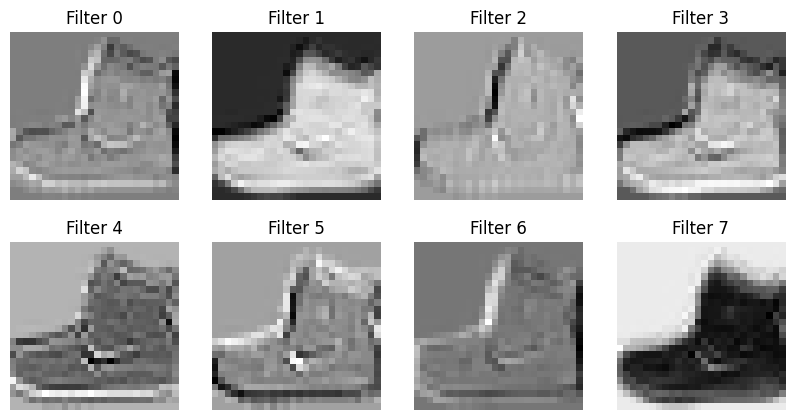

In [16]:
# Vizualizovati feature mape nakon prolaska kroz konvolucioni sloj
fig, ax = plt.subplots(2, 4, figsize=(10, 5))

for i in range(8):
    row = i // 4
    col = i % 4

    ax[row][col].imshow(feature_maps[0][i], cmap="gray")
    ax[row][col].set_title(f"Filter {i}")
    ax[row][col].axis("off")

plt.show()

In [17]:
# Definisati ReLU aktivacionu funkciju

relu = nn.ReLU()

In [18]:
# Primeniti ReLU aktivacionu funkciju nad feature mapama
with torch.no_grad():
    feature_maps_relu = relu(feature_maps)

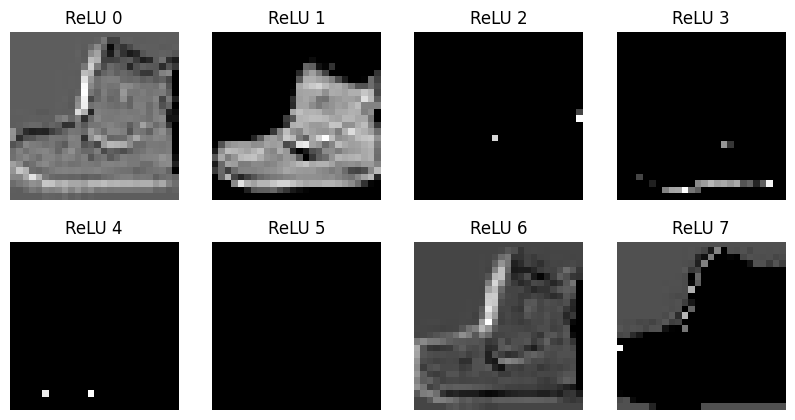

In [19]:
# Vizualizovati feature mape nakon primene ReLU funkcije

fig, ax = plt.subplots(2, 4, figsize=(10, 5))

for i in range(8):
    row = i // 4
    col = i % 4

    ax[row][col].imshow(feature_maps_relu[0][i], cmap="gray")
    ax[row][col].set_title(f"ReLU {i}")
    ax[row][col].axis("off")

plt.show()

In [20]:
# Definisati MaxPooling sloj

pool = nn.MaxPool2d(kernel_size=2)

In [21]:
# Primeniti pooling sloj nad feature mapama posle ReLU
with torch.no_grad():
    pooled_maps = pool(feature_maps_relu)

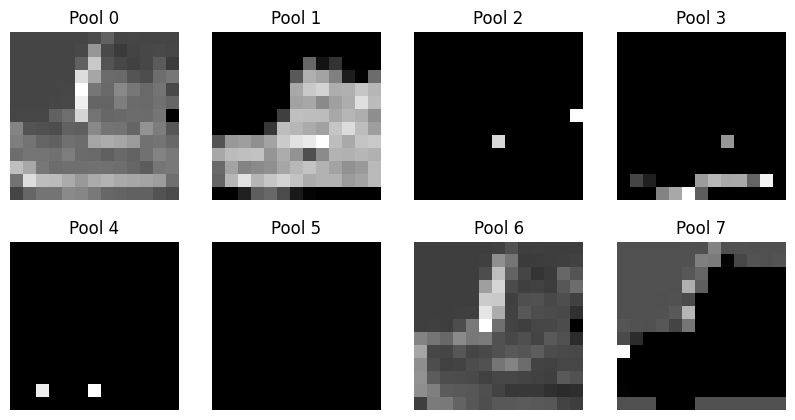

In [22]:
# Vizualizovati feature mape posle primene pooling sloja

fig, ax = plt.subplots(2, 4, figsize=(10, 5))

for i in range(8):
    row = i // 4
    col = i % 4

    ax[row][col].imshow(pooled_maps[0][i], cmap="gray")
    ax[row][col].set_title(f"Pool {i}")
    ax[row][col].axis("off")

plt.show()

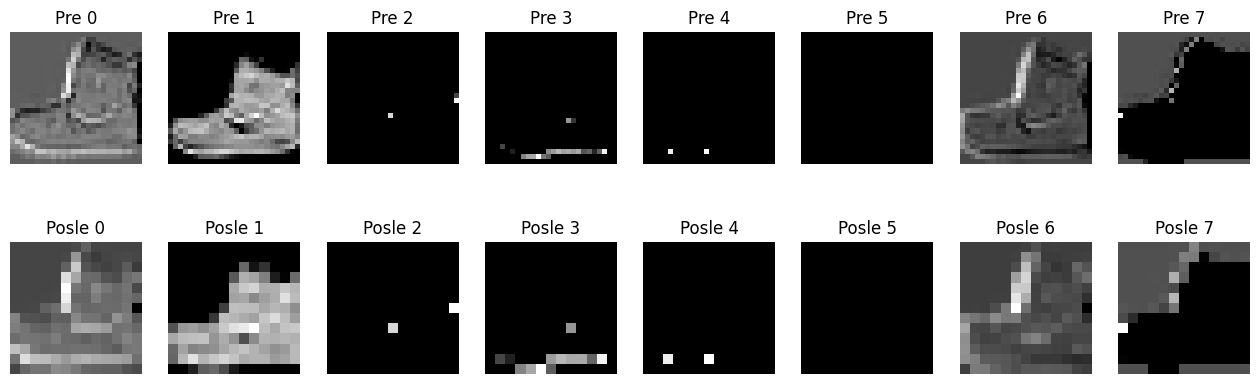

In [23]:
# Vizualizovati feature mape pre i posle pooling sloja
fig, ax = plt.subplots(2, 8, figsize=(16, 5))

for i in range(8):
    ax[0][i].imshow(feature_maps_relu[0][i], cmap="gray")
    ax[0][i].set_title(f"Pre {i}")
    ax[0][i].axis("off")

    ax[1][i].imshow(pooled_maps[0][i], cmap="gray")
    ax[1][i].set_title(f"Posle {i}")
    ax[1][i].axis("off")

plt.show()